<a href="https://colab.research.google.com/github/Ximearex/AI/blob/main/Fase_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**II. Conteste la siguiente preguntas abiertas de la manera correcta (20 puntos):**

*16. ¿Cómo funciona K-means para segmentar una imagen?*

Una imagen RGB esta formada por pixeles y cada uno se representa mediante 3 valores, cantidad de rojo, verde y azul. K-means toma todos los pixeles y forma grupos de colores parecidos llamados clusters. Esta técnica de clustering permite segmentar una imagen dividiendo sus píxeles en diferentes grupos o clusters de acuerdo con sus caracteristicas de intensidad o color.

Para aplicarlo se selecciona el numero de grupos K a obtener. El algoritmo coloca inicialmente K centroides y despues asigna cada pixel al centroide más cercano, normalmente utilizando la distancia euclidiana. Posteriormente, calcula nuevamente el centro de cada grupo y se repite hasta que los centroides dejen de cambiar.

Cada cluster puede interpretarse como una región diferente de la imagen, por ejemplo se pueden separar tejidos, huesos, entre otros que presenten diferencias de intensidad o color.

*17. ¿Por qué la umbralización puede fallar en imágenes médicas?*

Estos problemas aparecen cuando dos partes de una imagen tienen casi el mismo tono, ya que la umbralización trabaja de forma muy sencilla, segmenta una imagen clasificando los píxeles según su intensidad. Por ejemplo, se establece un umbral y todo lo que sea mayor pertenece a una región y lo que sea menor a otra.

Hablando de imagenes medicas como por ejemplo una RM donde la lesión y el tejido sano tienen casi el mismo nivel de gris, la computadora suele confundir donde termina una región e inicia otra.



**III. Resuelva  los siguiente problemas (50 puntos):**

**Ejercicio 1 - Segmentación y clustering (Fase 2)**

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
#cargar imagen de un virus
from google.colab import files
uploaded = files.upload()
RUTA_IMAGEN = list(uploaded.keys())[0]


Saving virus.jpg to virus (5).jpg


In [ ]:
# parámetros
GAUSS_K = 5          # kernel del suavizado gaussiano
GAUSS_SIGMA = 0
K_CLUSTERS = 3        # número de regiones para el clustering

In [ ]:
# K-means
def kmeans_numpy(X, k=3, max_iters=20):
    np.random.seed(0)
    indices = np.random.choice(X.shape[0], k, replace=False)
    centroids = X[indices]

    for _ in range(max_iters):
        distances = np.sqrt(((X[:, None] - centroids[None, :]) ** 2).sum(axis=2))
        labels = np.argmin(distances, axis=1)

        new_centroids = np.array([
            X[labels == i].mean(axis=0) if len(X[labels == i]) > 0 else centroids[i]
            for i in range(k)
        ])

        if np.allclose(centroids, new_centroids):
            break
        centroids = new_centroids

    return labels, centroids

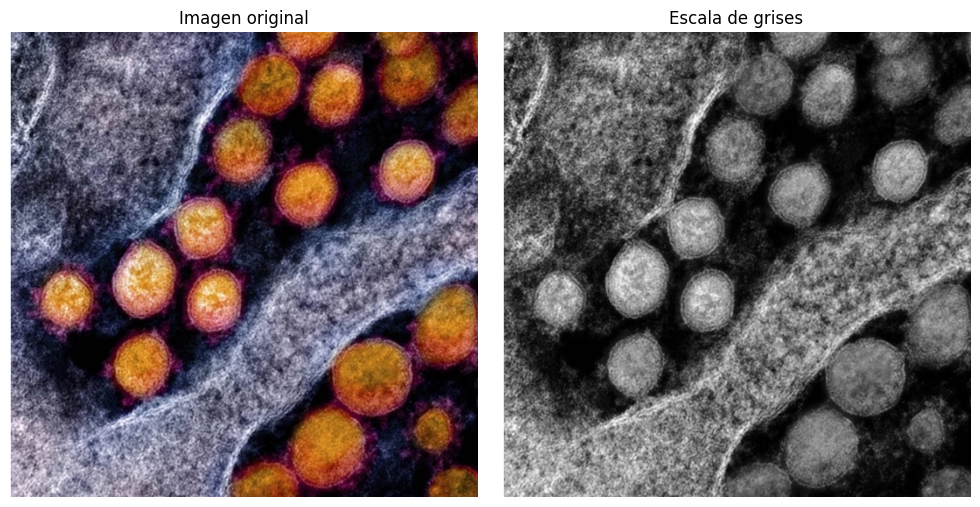

In [ ]:
# cargar imagen (color y gris)
img_bgr = cv2.imread(RUTA_IMAGEN)

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(img_rgb)
axs[0].set_title("Imagen original")
axs[0].axis("off")

axs[1].imshow(img_gray, cmap="gray")
axs[1].set_title("Escala de grises")
axs[1].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# segmentación por umbralización (Otsu)
img_blur = cv2.GaussianBlur(img_gray, (GAUSS_K, GAUSS_K), GAUSS_SIGMA)
otsu_thresh, seg_otsu = cv2.threshold(
    img_blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

In [ ]:
# clustering por color (k-means NumPy, k=3)
pixels = img_rgb.reshape(-1, 3).astype(np.float32)
labels, centers = kmeans_numpy(pixels, k=K_CLUSTERS)

segmented_pixels = centers[labels]
clustered_img = segmented_pixels.reshape(img_rgb.shape).astype(np.uint8)

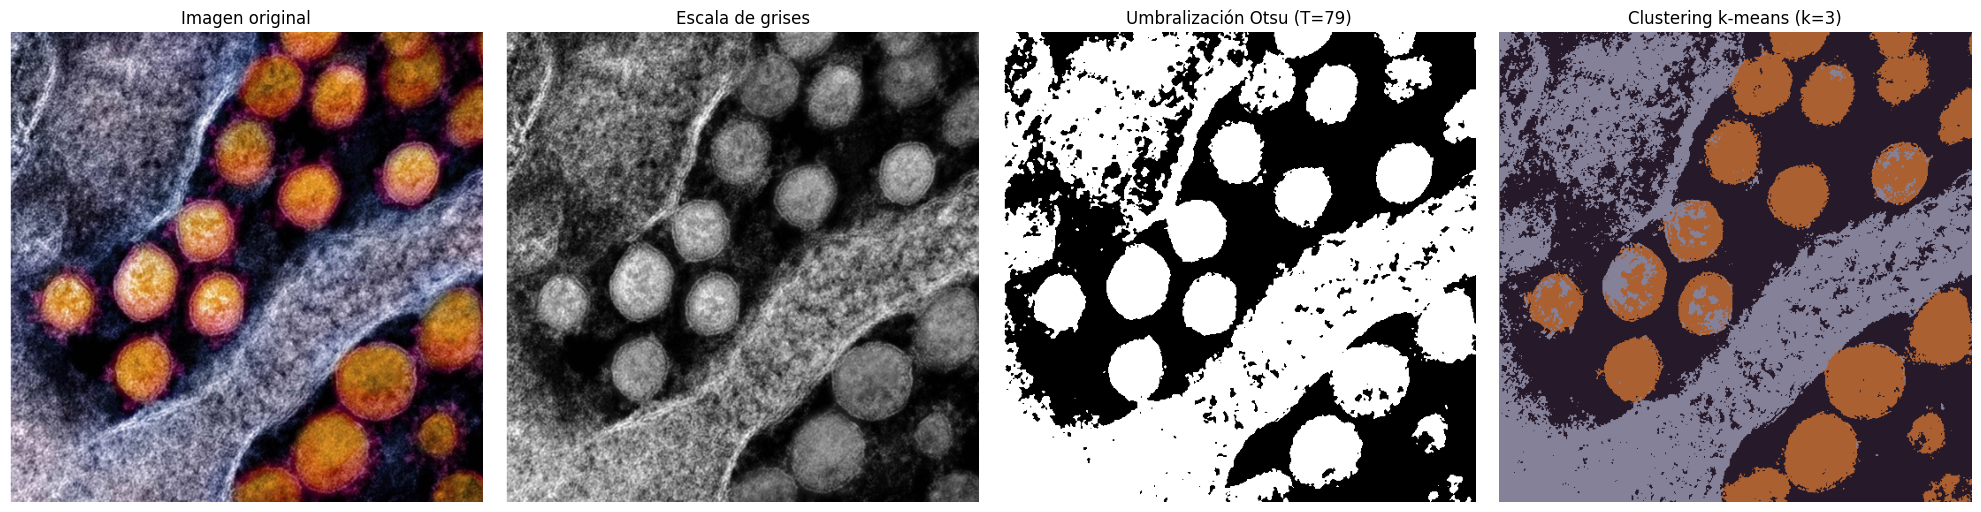

Umbral de Otsu calculado automáticamente: 79


In [ ]:
# panel comparativo
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(img_rgb)
axes[0].set_title("Imagen original")
axes[0].axis("off")

axes[1].imshow(img_gray, cmap="gray")
axes[1].set_title("Escala de grises")
axes[1].axis("off")

axes[2].imshow(seg_otsu, cmap="gray")
axes[2].set_title(f"Umbralización Otsu (T={int(otsu_thresh)})")
axes[2].axis("off")

axes[3].imshow(clustered_img)
axes[3].set_title(f"Clustering k-means (k={K_CLUSTERS})")
axes[3].axis("off")

plt.tight_layout()
plt.savefig("panel_ejercicio1.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Umbral de Otsu calculado automáticamente: {int(otsu_thresh)}")


La umbralización de Otsu (T≈79 en este caso) solo considera la intensidad de gris de cada píxel, por lo que separa la imagen en dos grupos: claro y oscuro. Esto captura bien las partículas más brillantes, pero también incorpora ruido de la textura del fondo, porque zonas claras del fondo caen en el mismo umbral que las partículas virales. El clustering k-means, en cambio, agrupa los píxeles usando los tres canales de color (R, G, B), lo que le permite distinguir el tono naranja/rosado de las partículas del tono gris-azulado del fondo con más precisión, dando 3 regiones más coherentes. En general, el clustering da una mejor segmentación pero es más costoso computacionalmente y depende de la inicialización de los centroides.

**Ejercicio 2 - Histogramas y mejora contraste (Fase 2)**

In [ ]:
#cargar imagen
from google.colab import files
uploaded = files.upload()
RUTA_IMAGEN_EJ2 = list(uploaded.keys())[0]

Saving tigre.jpg to tigre (6).jpg


In [ ]:
# parámetros
BETA_BRILLO = 50
ALPHA_CONTRASTE = 1.5

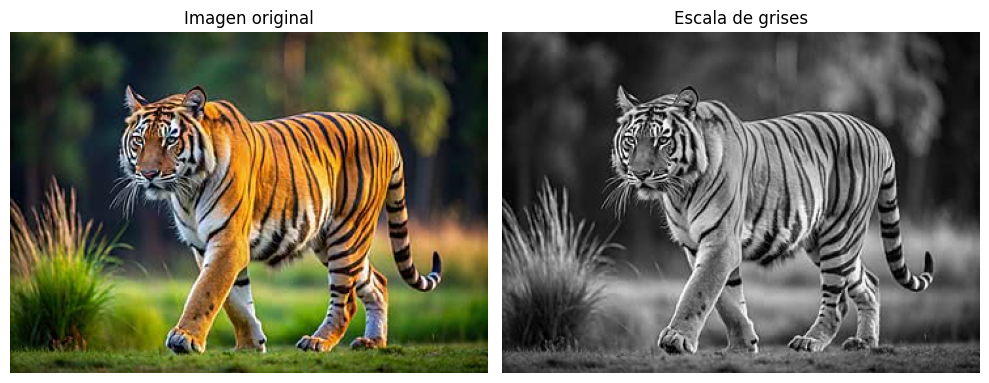

In [ ]:
# cargar y convertir a gris
img_bgr_ej2 = cv2.imread(RUTA_IMAGEN_EJ2)
img_rgb_ej2 = cv2.cvtColor(img_bgr_ej2, cv2.COLOR_BGR2RGB)
img_gray_ej2 = cv2.cvtColor(img_bgr_ej2, cv2.COLOR_BGR2GRAY)

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(img_rgb_ej2)
axs[0].set_title("Imagen original")
axs[0].axis("off")

axs[1].imshow(img_gray_ej2, cmap="gray")
axs[1].set_title("Escala de grises")
axs[1].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# transformaciones
img_brillo = cv2.convertScaleAbs(img_gray_ej2, alpha=1.0, beta=BETA_BRILLO)
img_contraste = cv2.convertScaleAbs(img_gray_ej2, alpha=ALPHA_CONTRASTE, beta=0)
img_ecualizada = cv2.equalizeHist(img_gray_ej2)

In [ ]:
# función de histograma
def hist(im):
    return cv2.calcHist([im], [0], None, [256], [0, 256]).ravel()

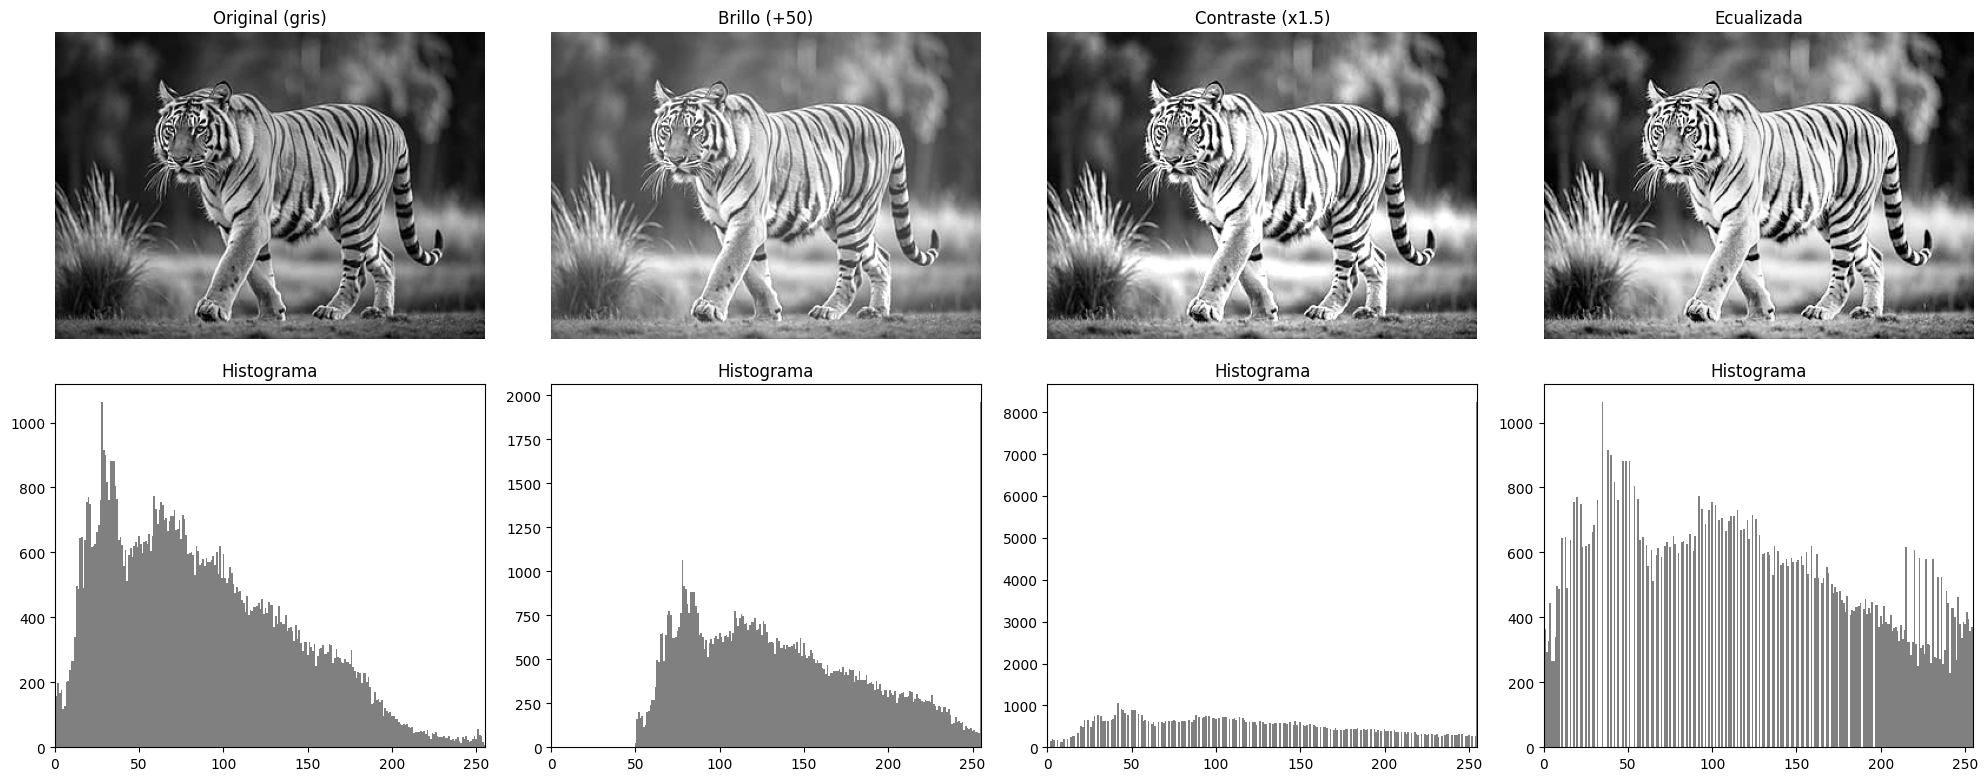

In [ ]:
# panel comparativo
imagenes = [img_gray_ej2, img_brillo, img_contraste, img_ecualizada]
titulos = ["Original (gris)", f"Brillo (+{BETA_BRILLO})", f"Contraste (x{ALPHA_CONTRASTE})", "Ecualizada"]

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
for i, (im, t) in enumerate(zip(imagenes, titulos)):
    axes[0, i].imshow(im, cmap="gray", vmin=0, vmax=255)
    axes[0, i].set_title(t)
    axes[0, i].axis("off")

    axes[1, i].bar(np.arange(256), hist(im), color="gray", width=1)
    axes[1, i].set_xlim([0, 255])
    axes[1, i].set_title("Histograma")

plt.tight_layout()
plt.savefig("panel_ejercicio2.png", dpi=150, bbox_inches="tight")
plt.show()

El histograma original mostró una distribución concentrada en tonos medios-bajos, típico de poco contraste. Al aumentar el brillo (+50), todo el histograma se desplazó hacia la derecha sin cambiar de forma, la imagen se aclara, pero el contraste real no mejora. Al aplicar el aumento de contraste (factor 1.5), el histograma se ensanchó hacia ambos extremos, mejorando la diferenciación visual entre estructuras. Finalmente, la ecualización redistribuyó automáticamente las intensidades para aprovechar todo el rango (0-255), dando el histograma más uniforme de los cuatro. Para un análisis clínico, la ecualización suele ser la más útil porque maximiza el contraste global y resalta estructuras difíciles de distinguir; sin embargo, puede amplificar ruido de fondo, por lo que en la práctica se prefieren variantes controladas como CLAHE (ecualización adaptativa por regiones).

**Ejercicio 3 - Transformaciones y filtrado**

In [ ]:
# cargar la imagen de RM en escala de grises
from google.colab import files
uploaded = files.upload()
RUTA_IMAGEN_EJ3 = list(uploaded.keys())[0]

img_gray_ej3 = cv2.imread(RUTA_IMAGEN_EJ3, cv2.IMREAD_GRAYSCALE)
h, w = img_gray_ej3.shape

Saving biomedica.jpg to biomedica (2).jpg


In [ ]:
# escalado (200%, 150%, 50%)
img_200 = cv2.resize(img_gray_ej3, None, fx=2.0, fy=2.0, interpolation=cv2.INTER_LINEAR)
img_150 = cv2.resize(img_gray_ej3, None, fx=1.5, fy=1.5, interpolation=cv2.INTER_LINEAR)
img_50 = cv2.resize(img_gray_ej3, None, fx=0.5, fy=0.5, interpolation=cv2.INTER_AREA)

# traslación entera (x=80, y=45)
tx, ty = 80, 45
M_trasl = np.float32([[1, 0, tx], [0, 1, ty]])
img_trasladada = cv2.warpAffine(img_gray_ej3, M_trasl, (w, h))

# rotación de 45° alrededor del centro
centro = (w // 2, h // 2)
M_rot = cv2.getRotationMatrix2D(centro, 45, 1.0)
img_rotada = cv2.warpAffine(img_gray_ej3, M_rot, (w, h))

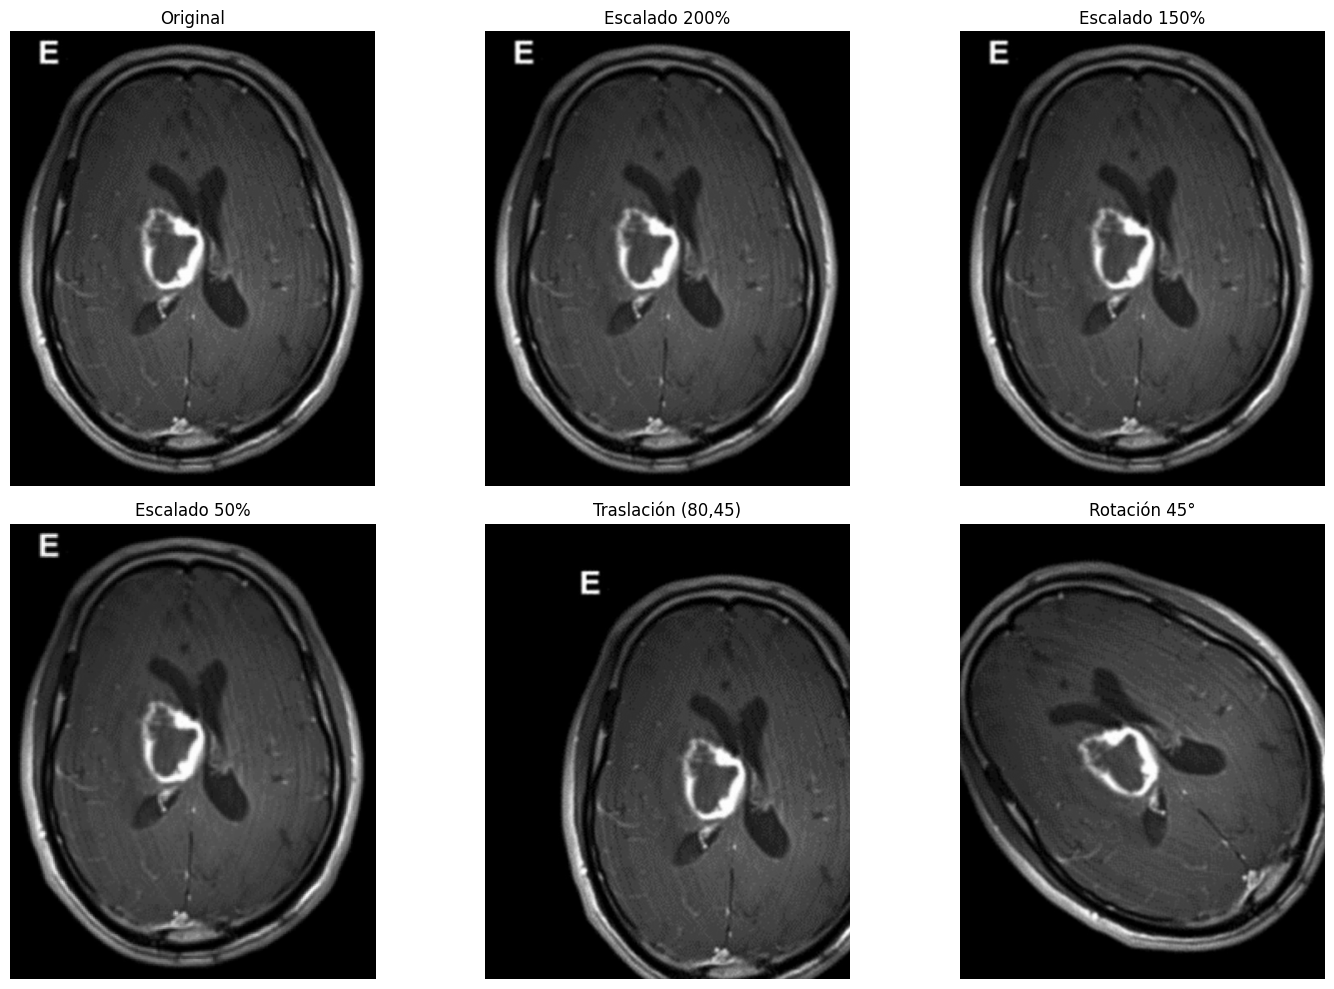

In [ ]:
# panel comparativo
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
items = [
    (img_gray_ej3, "Original"),
    (img_200, "Escalado 200%"),
    (img_150, "Escalado 150%"),
    (img_50, "Escalado 50%"),
    (img_trasladada, "Traslación (80,45)"),
    (img_rotada, "Rotación 45°"),
]
for ax, (im, t) in zip(axes.ravel(), items):
    ax.imshow(im, cmap="gray")
    ax.set_title(t)
    ax.axis("off")

plt.tight_layout()
plt.savefig("panel_ejercicio3.png", dpi=150, bbox_inches="tight")
plt.show()

Se aplicaron transformaciones geométricas (escalado, traslación y rotación) sobre la imagen de resonancia magnética proporcionada, verificando que cada operación preserva la información visual relevante de la estructura cerebral.